# Compound Weekly Net Flow Forecast — January 2026

Predict weekly organic net flow (`arrivals − departures`, transfers excluded) for each of the
12 compounds across the 4 weeks of January 2026.

## Structure
1. Data → weekly aggregation
2. Configuration
3. Walk-forward CV — 4-week-ahead, one fit per fold
4. Forecast quality metrics — RMSE, bias, coverage by compound × horizon
5. Final forecast — fit on all data, predict Jan 5 / 12 / 19 / 26
6. Residual ACF → optional AR correction


In [44]:
import sys, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sys.path.insert(0, '..')
from src.config import NET_FLOW_PROPHET_PARAMS
from src.preprocessing import flag_repair_cars, impute_repair_estimate
from src.forecasting import NetFlowForecaster, build_weekly_net

compute_metrics = NetFlowForecaster.compute_metrics

warnings.filterwarnings('ignore')


In [45]:
cd /Users/deryadurmush/Documents/FINN

/Users/deryadurmush/Documents/FINN


In [46]:
car_events = pd.read_csv('data/car_events.csv')
compounds  = pd.read_csv('data/compounds.csv')
transfers = pd.read_csv('data/transfers.csv')

car_events = flag_repair_cars(car_events, transfers)
car_events = impute_repair_estimate(car_events, mode = 'median')


In [47]:
car_events['event_date'] = pd.to_datetime(car_events['event_date'])

weekly_net = build_weekly_net(car_events, compounds)

REGION_ORDER = {'South': 0, 'West': 1, 'North': 2, 'East': 3}
cpd_meta = compounds.copy()
cpd_meta['r_order'] = cpd_meta['region'].map(REGION_ORDER)
COMPOUNDS = cpd_meta.sort_values(['r_order', 'compound_id'])['compound_id'].tolist()
CAP = compounds.set_index('compound_id')['total_capacity'].to_dict()


In [ ]:
inferred_cp = NetFlowForecaster.infer_changepoints_gradient(weekly_net, min_prominence=2.0, min_gap_weeks=3)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 11))
fig.suptitle(
    'Rolling-5 Net Flow — gradient zero-crossings as changepoint candidates\n'
    'Orange dots = detected turning points  ·  navy dashed = MANUAL_CHANGEPOINTS',
    fontsize=12, fontweight='bold'
)
GRID_LAYOUT = [
    ['CPD_MUNICH_01','CPD_MUNICH_02','CPD_STUTTGART_01','CPD_NUREMBERG_01'],
    ['CPD_COLOGNE_01','CPD_DUSSELDORF_01','CPD_FRANKFURT_01','CPD_HAMBURG_01'],
    ['CPD_BREMEN_01','CPD_BERLIN_01','CPD_LEIPZIG_01','CPD_DRESDEN_01'],
]
ROW_LABELS = ['South', 'West / North', 'North / East']

for row_idx, (row_cpds, row_label) in enumerate(zip(GRID_LAYOUT, ROW_LABELS)):
    for col_idx, cpd in enumerate(row_cpds):
        ax  = axes[row_idx, col_idx]
        sub = weekly_net[weekly_net['compound_id'] == cpd].sort_values('week_start')
        ax.plot(sub['week_start'], sub['rolling_net_flow'],
                color='steelblue', linewidth=1.4, zorder=3)
        ax.fill_between(sub['week_start'], sub['rolling_net_flow'], 0,
                        where=sub['rolling_net_flow'] >= 0,
                        color='#2ca02c', alpha=0.15)
        ax.fill_between(sub['week_start'], sub['rolling_net_flow'], 0,
                        where=sub['rolling_net_flow'] < 0,
                        color='#d62728', alpha=0.15)
        ax.axhline(0, color='black', linewidth=0.5, zorder=2)

        for cp_str in inferred_cp.get(cpd, []):
            cp_ts = pd.Timestamp(cp_str)
            row   = sub[sub['week_start'] == cp_ts]
            y_val = row['rolling_net_flow'].values[0] if not row.empty else 0
            ax.axvline(cp_ts, color='darkorange', linewidth=1.0, linestyle='-', alpha=0.6, zorder=4)
            ax.scatter([cp_ts], [y_val], color='darkorange', s=35, zorder=5)

        label = cpd.replace('CPD_', '').replace('_01', '')
        n_cp  = len(inferred_cp.get(cpd, []))
        ax.set_title(f'{label}  ({n_cp} turning pts)', fontsize=8.5, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=6.5)
        ax.tick_params(axis='y', labelsize=7)

    fig.text(0.01, 0.82 - row_idx * 0.31, row_label,
             fontsize=9, color='dimgray', rotation=90, va='center')

plt.tight_layout(rect=[0.02, 0, 1, 1])
plt.show()

print('Inferred changepoints (min_prominence=2.0):')
for cpd, cps in sorted(inferred_cp.items()):
    print(f'  {cpd:<25} {cps}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

# ── Forecast horizon ──────────────────────────────────────────────────────────
FORECAST_WEEKS  = [pd.Timestamp('2026-01-05'), pd.Timestamp('2026-01-12'),
                   pd.Timestamp('2026-01-19'), pd.Timestamp('2026-01-26')]
N_HORIZONS      = 4    # weeks ahead to evaluate in CV

# ── CV settings ───────────────────────────────────────────────────────────────
# min_train=52 → at least 1 full year before first prediction
MIN_TRAIN       = 52

# ── Prophet hyperparameters ───────────────────────────────────────────────────
# Loaded from src/config.py  NET_FLOW_PROPHET_PARAMS (tuned via grid search).
# To override a compound, add/edit its entry in config.NET_FLOW_PROPHET_PARAMS.
PROPHET_PARAMS = NET_FLOW_PROPHET_PARAMS

print('Configuration loaded.')
print(f'Forecast weeks: {[str(w.date()) for w in FORECAST_WEEKS]}')
print(f'CV: min_train={MIN_TRAIN} weeks, predict {N_HORIZONS} weeks ahead')

In [ ]:
# ── Hyperparameter grid search 

N_GS_FOLDS = 5

best_params = NetFlowForecaster.run_grid_search(weekly_net, compounds, changepoints=inferred_cp,
                              min_train=MIN_TRAIN, n_gs_folds=N_GS_FOLDS)

print()
print('Suggested NET_FLOW_PROPHET_PARAMS (copy into src/config.py):')
print('NET_FLOW_PROPHET_PARAMS = {')
for cpd, p in best_params.items():
    print(f"    '{cpd}': dict(changepoint_prior_scale={p['changepoint_prior_scale']}, "
          f"seasonality_prior_scale={p['seasonality_prior_scale']}, "
          f"fourier_order={p['fourier_order']}),")
print('}')

In [50]:
print(f'Running walk-forward CV  (min_train={MIN_TRAIN}, horizons={N_HORIZONS})...')
cv_results = NetFlowForecaster.run_network_cv(weekly_net, compounds, PROPHET_PARAMS,
                                              changepoints=inferred_cp,
                                              min_train=MIN_TRAIN, n_horizons=N_HORIZONS)

for cpd, cv in cv_results.items():
    label = cpd.replace('CPD_','').replace('_01','')
    h1    = cv[cv['horizon'] == 1]
    act   = h1['actual'].values; pred = h1['predicted'].values
    mape  = np.nanmean(np.abs((act - pred) / np.where(act == 0, np.nan, act)) * 100)
    print(f'  {label:18s}  folds={cv["fold"].nunique()}  h=1 MAPE={mape:.1f}%')
print('\nCV done.')

Running walk-forward CV  (min_train=52, horizons=4)...
  MUNICH              folds=50  h=1 MAPE=19.6%
  MUNICH_02           folds=50  h=1 MAPE=23.2%
  STUTTGART           folds=50  h=1 MAPE=15.1%
  NUREMBERG           folds=50  h=1 MAPE=19.6%
  COLOGNE             folds=50  h=1 MAPE=19.6%
  DUSSELDORF          folds=50  h=1 MAPE=23.8%
  FRANKFURT           folds=50  h=1 MAPE=20.6%
  HAMBURG             folds=50  h=1 MAPE=17.6%
  BREMEN              folds=50  h=1 MAPE=20.8%
  BERLIN              folds=50  h=1 MAPE=17.5%
  LEIPZIG             folds=24  h=1 MAPE=7.1%
  DRESDEN             folds=50  h=1 MAPE=23.9%

CV done.


In [51]:
# ── Summary tables: MAPE / bias / coverage by compound × horizon ─────────────
mape_table = pd.DataFrame(index=[c.replace('CPD_','').replace('_01','') for c in COMPOUNDS],
                           columns=[f'h={h}' for h in range(1, N_HORIZONS+1)])
bias_table = mape_table.copy()
cov_table  = mape_table.copy()

for cpd in COMPOUNDS:
    m_df  = compute_metrics(cv_results[cpd])
    label = cpd.replace('CPD_','').replace('_01','')
    for _, row in m_df.iterrows():
        mape_table.loc[label, f'h={int(row["horizon"])}'] = row['mape']
        bias_table.loc[label, f'h={int(row["horizon"])}'] = row['bias']
        cov_table.loc[label,  f'h={int(row["horizon"])}'] = row['coverage']

print('MAPE (%) by compound x horizon:')
print(mape_table.to_string())
print()
print('Bias (cars, + = overpredicting) by compound x horizon:')
print(bias_table.to_string())
print()
print('95% CI Coverage (%) by compound x horizon:')
print(cov_table.to_string())

ci0_table = mape_table.copy()
for cpd in COMPOUNDS:
    m_df  = compute_metrics(cv_results[cpd])
    label = cpd.replace('CPD_','').replace('_01','')
    for _, row in m_df.iterrows():
        ci0_table.loc[label, f'h={int(row["horizon"])}'] = row['ci_excl_0']
print()
print('CI excludes zero (%) — model is confidently +/- by compound x horizon:')
print(ci0_table.to_string())


MAPE (%) by compound x horizon:
             h=1   h=2   h=3   h=4
MUNICH      19.6  25.8  30.4  32.7
MUNICH_02   23.2  30.8  35.9  39.8
NUREMBERG   19.6  30.2  38.3  41.7
STUTTGART   15.1  19.7  21.7  23.5
COLOGNE     19.6  26.3  31.6  36.6
DUSSELDORF  23.8  30.6  32.9  34.1
FRANKFURT   20.6  30.5  38.8  42.2
BREMEN      20.8  27.5  33.0  37.7
HAMBURG     17.6  22.6  23.2  24.6
BERLIN      17.5  25.1  32.0  37.5
DRESDEN     23.9  28.5  31.8  33.8
LEIPZIG      7.1   9.4  11.2  12.0

Bias (cars, + = overpredicting) by compound x horizon:
            h=1  h=2   h=3   h=4
MUNICH      3.6  5.3   6.7   6.8
MUNICH_02   0.8  0.9   0.4  -0.2
NUREMBERG  -0.3 -0.0   0.2  -0.2
STUTTGART   1.6  2.2   2.2   1.6
COLOGNE     0.5  1.1   1.4   1.3
DUSSELDORF  1.8  2.5   2.9   2.8
FRANKFURT   1.2  2.2   3.2   4.1
BREMEN      0.5  0.6   0.3  -0.1
HAMBURG     1.9  3.3   4.3   4.1
BERLIN      2.2  2.9   3.0   1.7
DRESDEN     5.3  7.2   8.2   8.5
LEIPZIG     5.0  9.4  13.7  15.3

95% CI Coverage (%) by comp

In [ ]:
def analyse_bias_stability(cv_results, horizon=1):
    """
    For each compound, compute per-fold bias % (predicted - actual) / |actual|
    at a given horizon and assess whether the overprediction is stable
    (consistent direction + low variance) or erratic.

    Returns a summary DataFrame sorted by mean_bias_pct descending.
    Also plots weekly bias % over time so you can see if the error is
    structural or concentrated in specific periods.
    """
    rows = []
    bias_series = {}   # compound -> pd.Series(week -> bias_pct)

    for cpd, cv in cv_results.items():
        h = cv[cv['horizon'] == horizon].copy()
        h = h[h['actual'].abs() > 0]   # drop near-zero actuals (undefined %)
        if h.empty:
            continue

        bias_pct = (h['predicted'] - h['actual']) / h['actual'].abs() * 100
        label    = cpd.replace('CPD_', '').replace('_01', '')

        bias_series[label] = pd.Series(bias_pct.values, index=h['week'].values)

        rows.append(dict(
            compound       = label,
            mean_bias_pct  = round(bias_pct.mean(), 1),
            std_bias_pct   = round(bias_pct.std(),  1),
            cov            = round(bias_pct.std() / bias_pct.abs().mean(), 2)
                             if bias_pct.abs().mean() > 0 else np.nan,
            overpred_rate  = round((bias_pct > 0).mean() * 100, 0),  # % of weeks overpredicted
            n_folds        = len(bias_pct),
        ))

    summary = (
        pd.DataFrame(rows)
        .sort_values('mean_bias_pct', ascending=False)
        .reset_index(drop=True)
    )

    # ── Verdict ──────────────────────────────────────────────────────────────
    def verdict(row):
        op = row['overpred_rate']
        cov = row['cov']
        if op >= 75 and cov < 1.5:  return 'systematic over'
        if op <= 25 and cov < 1.5:  return 'systematic under'
        if cov < 1.5:               return 'small + stable'
        return 'variable'
    summary['verdict'] = summary.apply(verdict, axis=1)

    print(f'Bias stability — h={horizon} (+ = overprediction)\n')
    print(summary.to_string(index=False))

    # ── Plot: bias % over time per compound ───────────────────────────────────
    GRID_SHAPE = (3, 4)
    fig, axes = plt.subplots(*GRID_SHAPE, figsize=(20, 11), sharex=False)
    fig.suptitle(
        f'Weekly bias % (predicted − actual) / |actual|  ·  horizon={horizon}\n'
        f'Stable = same sign every week   Variable = sign flips',
        fontsize=12,
    )

    cpd_order = [c.replace('CPD_', '').replace('_01', '') for c in COMPOUNDS]
    for ax, label in zip(axes.flat, cpd_order):
        s = bias_series.get(label)
        if s is None or s.empty:
            ax.set_visible(False)
            continue

        row = summary[summary['compound'] == label].iloc[0]
        color = ('#d62728' if row['verdict'] == 'systematic over'
                 else '#1f77b4' if row['verdict'] == 'systematic under'
                 else '#7f7f7f')

        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.axhline(row['mean_bias_pct'], color=color, linewidth=1.2,
                   linestyle=':', label=f'mean={row["mean_bias_pct"]:+.1f}%')
        ax.plot(s.index, s.values, color=color, linewidth=0.9, alpha=0.8)
        ax.fill_between(s.index, 0, s.values,
                         where=(s.values > 0), color='#d62728', alpha=0.12)
        ax.fill_between(s.index, 0, s.values,
                         where=(s.values < 0), color='#1f77b4', alpha=0.12)

        ax.set_title(
            f'{label}  [{row["verdict"]}]\n'
            f'mean={row["mean_bias_pct"]:+.1f}%  std={row["std_bias_pct"]:.1f}%  '
            f'over={int(row["overpred_rate"])}% of weeks',
            fontsize=8,
        )
        ax.tick_params(labelsize=7)
        ax.set_ylabel('bias %', fontsize=7)

    plt.tight_layout()
    plt.show()
    return summary

bias_summary = analyse_bias_stability(cv_results, horizon=1)

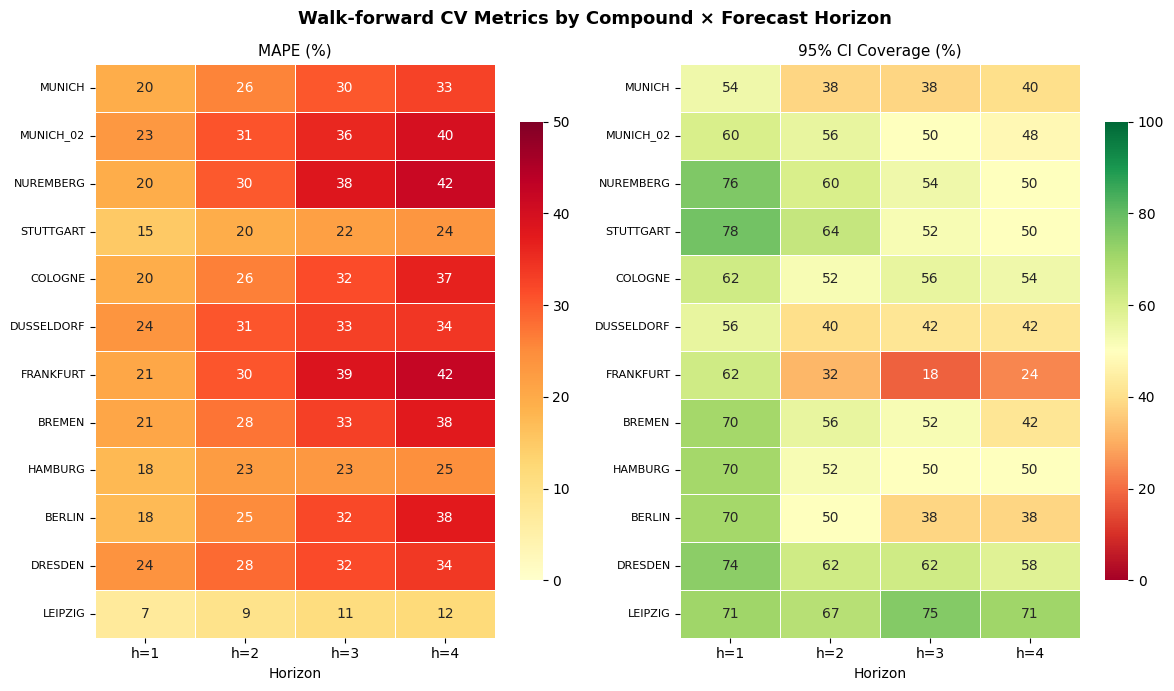

Saved → docs/weekly_cv_metrics_heatmap.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
fig.suptitle('Walk-forward CV Metrics by Compound × Forecast Horizon', fontsize=13, fontweight='bold')

tables = [
    (mape_table.astype(float), 'MAPE (%)',             'YlOrRd',  0,  50, False),
    # (bias_table.astype(float), 'Bias (cars, + = over)','RdBu',   -15, 15, False),
    (cov_table.astype(float),  '95% CI Coverage (%)',  'RdYlGn',   0, 100, False),
]
for ax, (tbl, title, cmap, vmin, vmax, _) in zip(axes, tables):
    sns.heatmap(tbl, annot=True, fmt='.0f', cmap=cmap, vmin=vmin, vmax=vmax,
                linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Horizon'); ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()



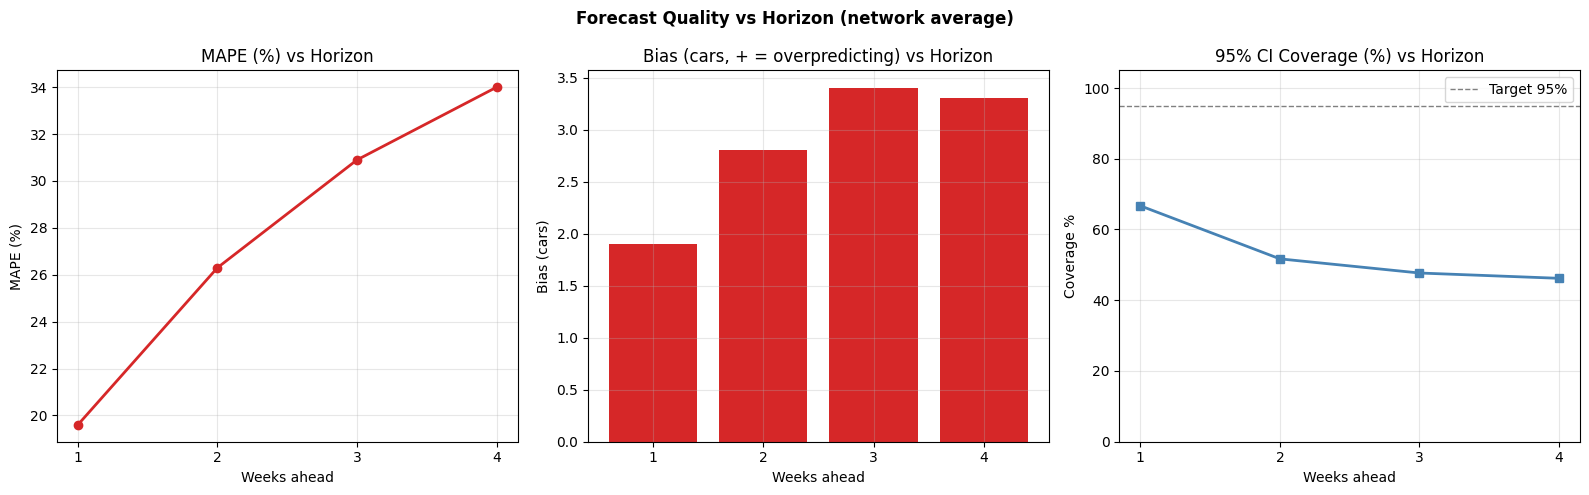

Saved → docs/weekly_cv_degradation.png

Network-average metrics by horizon:
 horizon  mape  mae  bias  coverage  ci_excl_0
       1  19.6 12.2   1.9      66.7       99.3
       2  26.3 16.5   2.8      51.7       97.0
       3  30.9 19.5   3.4      47.7       95.8
       4  34.0 21.4   3.3      46.2       95.1


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Forecast Quality vs Horizon (network average)', fontsize=12, fontweight='bold')

all_cv = pd.concat(cv_results.values(), ignore_index=True)
agg    = compute_metrics(all_cv)

axes[0].plot(agg['horizon'], agg['mape'], 'o-', color='#d62728', linewidth=2)
axes[0].set_title('MAPE (%) vs Horizon')
axes[0].set_xlabel('Weeks ahead'); axes[0].set_ylabel('MAPE (%)')
axes[0].set_xticks(range(1, N_HORIZONS+1)); axes[0].grid(alpha=0.3)

axes[1].bar(agg['horizon'], agg['bias'],
            color=['#d62728' if v > 0 else '#2ca02c' for v in agg['bias']])
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].set_title('Bias (cars, + = overpredicting) vs Horizon')
axes[1].set_xlabel('Weeks ahead'); axes[1].set_ylabel('Bias (cars)')
axes[1].set_xticks(range(1, N_HORIZONS+1)); axes[1].grid(alpha=0.3)

axes[2].plot(agg['horizon'], agg['coverage'], 's-', color='steelblue', linewidth=2)
axes[2].axhline(95, color='gray', linewidth=1, linestyle='--', label='Target 95%')
axes[2].set_title('95% CI Coverage (%) vs Horizon')
axes[2].set_xlabel('Weeks ahead'); axes[2].set_ylabel('Coverage %')
axes[2].set_xticks(range(1, N_HORIZONS+1)); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()
print()
print(agg[['horizon','mape','mae','bias','coverage','ci_excl_0']].to_string(index=False))


---
## Final Forecast — January 2026 (4 weeks)

Fit on the **full 105-week history** per compound. AR correction applied where
residual ACF shows significant lag-1+ autocorrelation.


In [55]:
final_df = NetFlowForecaster.run_network_forecast(weekly_net, compounds, PROPHET_PARAMS,
                                                  FORECAST_WEEKS, changepoints=inferred_cp)

print('Net Flow Forecast — January 2026  (cumulative, logistic Prophet + AR)')
print(f'{"Compound":18s}  {"Region":6s}  {"h":>3s}  {"Week":>12s}  {"Predicted":>10s}  '
      f'{"Lower 95":>9s}  {"Upper 95":>9s}  {"CI Width":>9s}  Model')
print('─' * 100)
for _, row in final_df.iterrows():
    model_tag = f'P+AR({row["ar_order"]})' if row['ar_order'] > 0 else 'Prophet'
    print(f'{row["compound"]:18s}  {row["region"]:6s}  h={row["horizon"]}  '
          f'{str(row["week"]):>12s}  {row["predicted"]:>+10.1f}  '
          f'{row["lower_95"]:>+9.1f}  {row["upper_95"]:>+9.1f}  '
          f'{row["upper_95"]-row["lower_95"]:>9.1f}  {model_tag}')
    if row['horizon'] == N_HORIZONS:
        print()

net_totals = final_df.groupby('week')[['predicted','lower_95','upper_95']].sum()
print('Network total per week:')
print(net_totals.round(0).to_string())

Net Flow Forecast — January 2026  (cumulative, logistic Prophet + AR)
Compound            Region    h          Week   Predicted   Lower 95   Upper 95   CI Width  Model
────────────────────────────────────────────────────────────────────────────────────────────────────
MUNICH              South   h=1    2026-01-05      +159.6     +129.0     +191.4       62.4  Prophet
MUNICH              South   h=2    2026-01-12      +167.1     +135.6     +200.4       64.8  Prophet
MUNICH              South   h=3    2026-01-19      +178.7     +145.9     +210.1       64.2  Prophet
MUNICH              South   h=4    2026-01-26      +184.5     +149.5     +214.9       65.4  Prophet

MUNICH_02           South   h=1    2026-01-05       +71.6      +61.1      +82.5       21.4  Prophet
MUNICH_02           South   h=2    2026-01-12       +70.3      +59.9      +80.7       20.8  Prophet
MUNICH_02           South   h=3    2026-01-19       +68.4      +58.1      +78.6       20.5  Prophet
MUNICH_02           South   h=

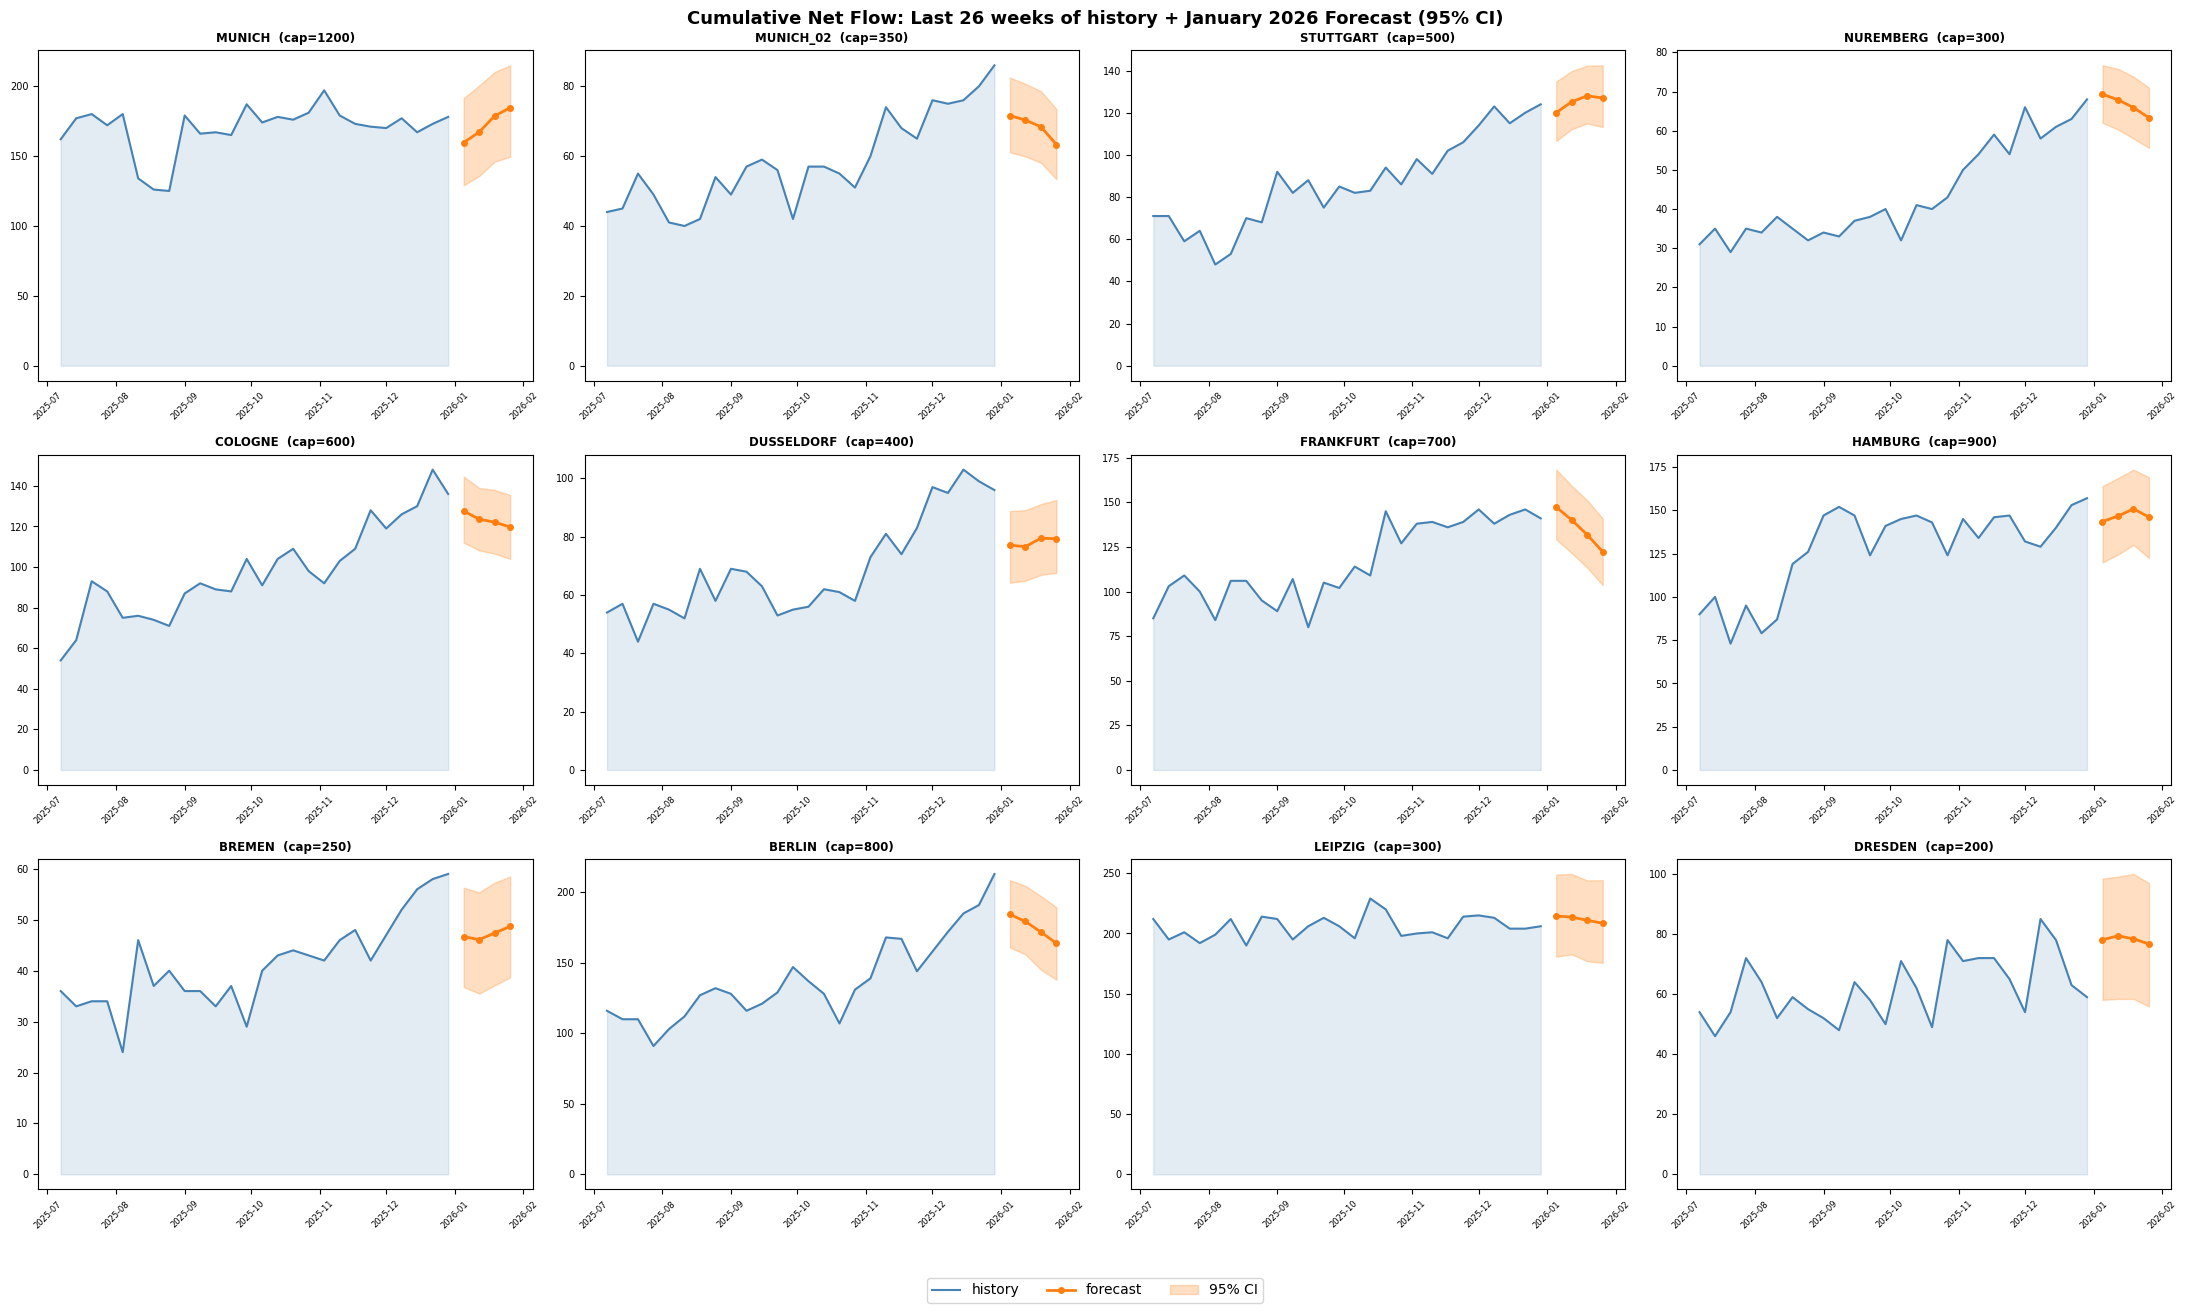

Saved → docs/weekly_net_flow_forecast_jan2026.png


In [ ]:
GRID = [
    ['CPD_MUNICH_01','CPD_MUNICH_02','CPD_STUTTGART_01','CPD_NUREMBERG_01'],
    ['CPD_COLOGNE_01','CPD_DUSSELDORF_01','CPD_FRANKFURT_01','CPD_HAMBURG_01'],
    ['CPD_BREMEN_01','CPD_BERLIN_01','CPD_LEIPZIG_01','CPD_DRESDEN_01'],
]

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
fig.suptitle('Cumulative Net Flow: Last 26 weeks of history + January 2026 Forecast (95% CI)',
             fontsize=13, fontweight='bold')

for row_idx, row_cpds in enumerate(GRID):
    for col_idx, cpd in enumerate(row_cpds):
        ax    = axes[row_idx, col_idx]
        sub   = weekly_net[weekly_net['compound_id']==cpd].sort_values('week_start')
        label = cpd.replace('CPD_','').replace('_01','')
        cap   = CAP[cpd]

        hist = sub.tail(26)
        ax.plot(hist['week_start'], hist['net_flow'],
                color='steelblue', linewidth=1.5, label='history')
        ax.fill_between(hist['week_start'], hist['net_flow'],
                        alpha=0.15, color='steelblue')

        fc_cpd = final_df[final_df['compound'] == label].sort_values('week')
        fc_weeks = pd.to_datetime(fc_cpd['week'])
        ax.plot(fc_weeks, fc_cpd['predicted'],
                color='#ff7f0e', linewidth=2, marker='o', markersize=4, label='forecast')
        ax.fill_between(fc_weeks, fc_cpd['lower_95'], fc_cpd['upper_95'],
                        alpha=0.25, color='#ff7f0e', label='95% CI')

        ax.set_title(f'{label}  (cap={cap})', fontsize=8.5, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.tick_params(axis='y', labelsize=7)

handles, labels_leg = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()



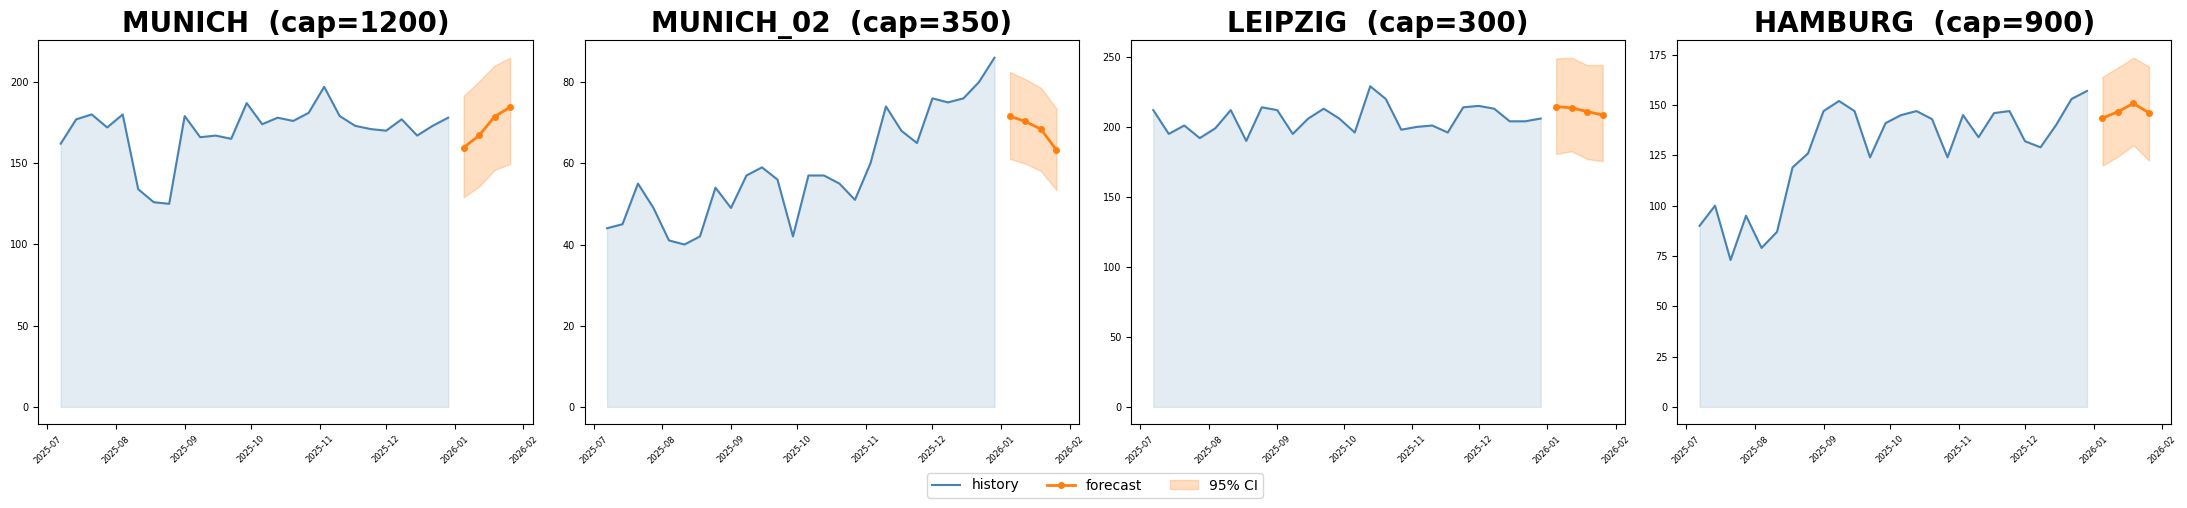

In [70]:
GRID = [
['CPD_MUNICH_01', 'CPD_MUNICH_02', 'CPD_LEIPZIG_01', 'CPD_HAMBURG_01'],
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = [axes]  # wrap in list so row_idx indexing still works
# fig.suptitle('Cumulative Net Flow: Last 26 weeks of history + January 2026 Forecast (95% CI)',
#         fontsize=13, fontweight='bold')

for row_idx, row_cpds in enumerate(GRID):
        for col_idx, cpd in enumerate(row_cpds):
                ax    = axes[row_idx][col_idx]
                sub   = weekly_net[weekly_net['compound_id']==cpd].sort_values('week_start')
                label = cpd.replace('CPD_','').replace('_01','')
                cap   = CAP[cpd]

                hist = sub.tail(26)
                ax.plot(hist['week_start'], hist['net_flow'],
                        color='steelblue', linewidth=1.5, label='history')
                ax.fill_between(hist['week_start'], hist['net_flow'],
                                alpha=0.15, color='steelblue')

                fc_cpd = final_df[final_df['compound'] == label].sort_values('week')
                fc_weeks = pd.to_datetime(fc_cpd['week'])
                ax.plot(fc_weeks, fc_cpd['predicted'],
                        color='#ff7f0e', linewidth=2, marker='o', markersize=4, label='forecast')
                ax.fill_between(fc_weeks, fc_cpd['lower_95'], fc_cpd['upper_95'],
                                alpha=0.25, color='#ff7f0e', label='95% CI')

                ax.set_title(f'{label}  (cap={cap})', fontsize=20, fontweight='bold')
                ax.tick_params(axis='x', rotation=45, labelsize=6)
                ax.tick_params(axis='y', labelsize=7)

handles, labels_leg = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3, fontsize=10,
        bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [ ]:
# CV metrics per compound
cv_metrics_rows = []
for cpd in COMPOUNDS:
    m_df = compute_metrics(cv_results[cpd])
    m_df['compound'] = cpd.replace('CPD_','').replace('_01','')
    cv_metrics_rows.append(m_df)
cv_metrics_all = pd.concat(cv_metrics_rows, ignore_index=True)



Saved → data/outputs/weekly_net_flow_forecast_jan2026.csv
Saved → data/outputs/weekly_cv_metrics.csv


In [ ]:
def build_forecast_tables(final_df, cv_results, horizon):
    """
    Build a summary table for a given forecast horizon.
    Rows = compounds, columns = predicted, Y_low, Y_high,
    CV MAPE, CV bias, CV coverage.
    """
    rows = []
    for cpd in COMPOUNDS:
        label = cpd.replace('CPD_', '').replace('_01', '').title()

        fc = final_df[(final_df['compound_id'] == cpd) &
                      (final_df['horizon'] == horizon)]
        if fc.empty:
            continue
        fc = fc.iloc[0]

        metrics = compute_metrics(cv_results[cpd])
        m = metrics[metrics['horizon'] == horizon]
        if m.empty:
            continue
        m = m.iloc[0]

        rows.append(dict(
            Compound        = label,
            Predicted       = int(round(float(fc['predicted']))),
            Y_Low           = int(round(float(fc['lower_95']))),
            Y_High          = int(round(float(fc['upper_95']))),
            CV_MAPE_pct     = round(float(m['mape']), 1),
            CV_Bias         = int(round(float(m['bias']))),
            CV_Coverage_pct = round(float(m['coverage']), 1),
        ))

    return pd.DataFrame(rows).set_index('Compound')

def print_slide_table(df, title):
    """Print a clean table ready to paste into a slide."""
    print(f'\n{title}')
    print('=' * (len(title) + 2))
    print(f"{'Compound':18s} | {'Predicted':>9s} | {'Y Low':>7s} | {'Y High':>7s} | {'CV MAPE':>8s} | {'CV Bias':>8s} | {'CV Cov':>7s}")
    print('-' * 80)
    for compound, row in df.iterrows():
        print(
            f"{compound:18s} | {int(row['Predicted']):>9d} | {int(row['Y_Low']):>7d} | "
            f"{int(row['Y_High']):>7d} | {row['CV_MAPE_pct']:>7.1f}% | {int(row['CV_Bias']):>+8d} | "
            f"{row['CV_Coverage_pct']:>6.1f}%"
        )

table_h1 = build_forecast_tables(final_df, cv_results, horizon=1)
table_h4 = build_forecast_tables(final_df, cv_results, horizon=4)

print_slide_table(table_h1, 'Week 1 Forecast — January 2026  (h=1)')
print_slide_table(table_h4, '4-Week Forecast — January 2026  (h=4)')

print('\n--- DataFrames ---')
print('\ntable_h1:')
display(table_h1)
print('\ntable_h4:')
display(table_h4)